# Practical 17: Object Detection from R-CNN ➜ Fast R-CNN ➜ Faster R-CNN ➜ Mask R-CNN

This notebook walks you step by step through the **R-CNN family**:
- **R-CNN → Fast R-CNN → Faster R-CNN → Mask R-CNN**  
Each improves speed and accuracy over the previous by (1) sharing computation and (2) learning proposals.

**What you'll do:**
1. Load a small dataset and prepare labels.
2. Train or load pretrained detectors.
3. Visualize predictions 
4. Evaluate (precision/recall/IoU) and compare models.

We will build from classic region-based detectors to modern two-stage and instance segmentation models.

  **Goal:** Understand the evolution of region-based detectors (R‑CNN family), then implement & fine‑tune **Faster R‑CNN** and **Mask R‑CNN** on a small, laptop‑friendly dataset. We’ll also provide mini‑demos to illustrate the older ideas (R‑CNN and Fast R‑CNN).



## Learning Objectives
By the end of this practical you will be able to:
1. Explain how **R‑CNN**, **Fast R‑CNN**, **Faster R‑CNN**, and **Mask R‑CNN** differ.
2. Describe how **region proposals** evolved from Selective Search to a learned **Region Proposal Network (RPN)**.
3. Implement a small **dataset loader** for instance‑segmentation data (Penn‑Fudan).
4. **Fine‑tune** torchvision’s `fasterrcnn_resnet50_fpn` and `maskrcnn_resnet50_fpn` on a small dataset.
5. Evaluate models with **IoU**, **precision/recall**, and **(mini) mAP@0.5** and compare inference speed.



## Roadmap (connects to previous practicals)
- **Prac 7–15:** You learned CNN backbones (AlexNet → EfficientNet) & transfer learning. Those backbones are reused here as the **feature extractors** of detection models.
- **Prac 16 (ViT):** Transformer backbones can also be used inside detection frameworks (e.g., DETR), but today we focus on the classic **R‑CNN family**.
- **Today:** We climb the evolution ladder: **R‑CNN → Fast R‑CNN → Faster R‑CNN → Mask R‑CNN**.
- **Next time:** We pivot to **YOLO**, a single‑stage family that trades a bit of accuracy for speed.



## 0. Setup

This notebook aims to run **locally** on a modest laptop (CPU works, GPU recommended).  
We’ll use a tiny academic dataset: **Penn‑Fudan Pedestrian** (≈170 images) which has **instance masks and bounding boxes**, perfect for Faster/Mask R‑CNN demos.


## 1. Conceptual Warm‑Up: The R‑CNN Family

### 1.1 R‑CNN (2014)
- **Idea:** Generate ~2k **region proposals** per image using **Selective Search** (hand‑crafted).  
- **For each proposal:** Crop & warp to a fixed size, pass through a **CNN** to extract features, then classify with **SVM**; regress boxes with linear regression; apply **NMS**.
- **Pros:** Big accuracy jump vs. classic methods.  
- **Cons:** **Very slow**: thousands of CNN forward passes **per image**.

### 1.2 Fast R‑CNN (2015)
- **Idea:** Run the CNN **once** for the whole image to produce a feature map, then use **ROI Pooling** (or ROI Align) to extract fixed‑size features for each proposal. Train end‑to‑end with softmax (classification) and smooth‑L1 (bbox regression).
- **Pros:** Much **faster** than R‑CNN; end‑to‑end training.  
- **Cons:** Still depends on **external proposals** (Selective Search), which is slow.

### 1.3 Faster R‑CNN (2015)
- **Idea:** Replace external proposals with a **Region Proposal Network (RPN)** that sits on top of the CNN features and proposes regions **learned** end‑to‑end.  
- **Pros:** **Fast + accurate**; end‑to‑end; became a strong standard for two‑stage detectors.

### 1.4 Mask R‑CNN (2017)
- **Idea:** Extend Faster R‑CNN by adding a parallel branch to predict a **binary mask** for each ROI (instance segmentation). Uses **ROI Align** to avoid mis‑alignment.  
- **Pros:** Detects **what** and **where** (box) and **which pixels** (mask) for each instance.



> **Mental Model:**  
> - R‑CNN = *classify each proposed crop with a CNN.*  
> - Fast R‑CNN = *run CNN once → ROI Pool features per proposal.*  
> - Faster R‑CNN = *learn to propose (RPN) + Fast R‑CNN head.*  
> - Mask R‑CNN = *Faster R‑CNN + per‑ROI mask branch (pixel‑wise).*



## 2. Dataset: Penn‑Fudan Pedestrian 

- **URL:** https://www.cis.upenn.edu/~jshi/ped_html/  
- ~170 images of people walking on city streets. Each person has a **mask** (so we can get **boxes** from masks) and an **instance ID**.
- We’ll split into train/val/test and create a PyTorch Dataset that returns:
  ```python
  image: Tensor[C,H,W]
  target: {
    boxes: Tensor[N,4] (xyxy),
    labels: Tensor[N] (1 = person),
    masks:  Tensor[N,H,W] (0/1),
    image_id, area, iscrowd
  }
  ```

In [ ]:

import os, zipfile, urllib.request, shutil, random, math
from pathlib import Path

DATA_DIR = Path("data/penn_fudan")
DATA_DIR.mkdir(parents=True, exist_ok=True)

url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
zip_path = DATA_DIR / "PennFudanPed.zip"
extract_dir = DATA_DIR / "PennFudanPed"

if not extract_dir.exists():
    print("Downloading Penn-Fudan dataset (~27MB)...")
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(DATA_DIR)
        print("Extracted to", extract_dir)
    except Exception as e:
        print("Download failed. If you have the ZIP, place it at", zip_path)
else:
    print("Dataset already present at", extract_dir)

# Simple train/val/test split (IDs are image names)
images = sorted((extract_dir / "PNGImages").glob("*.png"))
ids = [p.stem for p in images]
random.seed(17)
random.shuffle(ids)

n = len(ids)
train_ids = ids[: int(0.6*n)]
val_ids   = ids[int(0.6*n): int(0.8*n)]
test_ids  = ids[int(0.8*n):]

print(f"Total images: {n} | train:{len(train_ids)} val:{len(val_ids)} test:{len(test_ids)}")


Dataset already present at data\penn_fudan\PennFudanPed
Total images: 170 | train:102 val:34 test:34


In [ ]:

import torch
import torchvision
import numpy as np
from PIL import Image
import torchvision.transforms.functional as F
import cv2

class PennFudanDataset(torch.utils.data.Dataset):
    """Returns (image, target) for detection/instance segmentation.
    - image: FloatTensor [C,H,W] in [0,1]
    - target: dict with boxes, labels, masks, image_id, area, iscrowd
    """
    def __init__(self, root, id_list, transforms=None):
        self.root = Path(root)
        self.id_list = list(id_list)
        self.transforms = transforms
        self.img_dir = self.root / "PNGImages"
        self.mask_dir = self.root / "PedMasks"

    def __len__(self):
        return len(self.id_list)

    def __getitem__(self, idx):
        img_id = self.id_list[idx]
        img_path = self.img_dir / f"{img_id}.png"
        mask_path = self.mask_dir / f"{img_id}_mask.png"

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        mask_np = np.array(mask)  # each instance has a different gray value
        obj_ids = np.unique(mask_np)
        obj_ids = obj_ids[1:]  # first id is background (0)

        masks = mask_np == obj_ids[:, None, None]
        num_objs = len(obj_ids)

        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        labels = torch.ones((num_objs,), dtype=torch.int64)  # 1=person
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        image = F.to_tensor(img)  # [0,1]
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
            "img_name": img_id
        }
        if self.transforms:
            image = self.transforms(image)
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_ds = PennFudanDataset(extract_dir, train_ids)
val_ds   = PennFudanDataset(extract_dir, val_ids)
test_ds  = PennFudanDataset(extract_dir, test_ids)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn)

print("Dataloaders ready")


✔️ Dataloaders ready


### Visual Check


**How we draw boxes (quick refresher):**
- A bounding box is defined by two corners: `(x_min, y_min)` (top-left) and `(x_max, y_max)` (bottom-right).
- We use **red** boxes to make detections stand out.


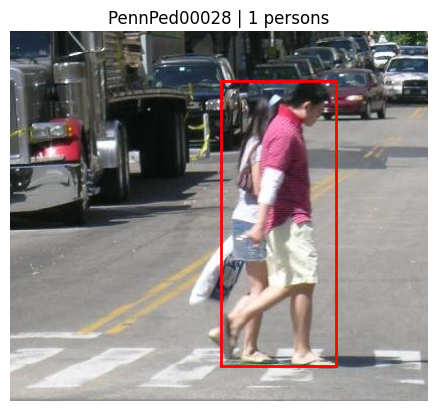

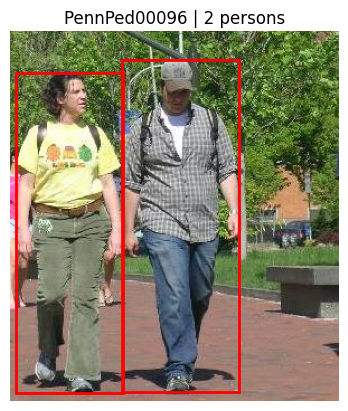

In [4]:

import matplotlib.pyplot as plt

def show_sample(ds, k=3):
    import numpy as np
    idxs = np.random.choice(len(ds), size=k, replace=False)
    for idx in idxs:
        img, tgt = ds[idx]
        img_np = img.permute(1,2,0).numpy()
        plt.figure()
        plt.imshow(img_np)
        for (xmin, ymin, xmax, ymax) in tgt["boxes"]:
            # NOTE: Matplotlib uses edgecolor to set box outline color. We choose 'red'.
            plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, 
                                              fill=False, linewidth=2, edgecolor='red'))
        plt.title(f"{tgt['img_name']} | {len(tgt['boxes'])} persons")
        plt.axis('off')
        plt.show()

show_sample(train_ds, k=2)


## 3. Demo: The R‑CNN Way (Selective Search + per‑proposal CNN features)

> **This is a teaching demo**, not a full training pipeline. It uses **OpenCV Selective Search** to propose regions, extracts **ResNet‑50** features for each crop, and trains a tiny **logistic regression** to classify "person vs. not‑person" on a handful of proposals. It’s intentionally small so it can run quickly on CPU.


In [ ]:

import torch, torchvision, numpy as np, cv2
from torchvision.models import resnet50
from sklearn.linear_model import LogisticRegression

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feat_extractor = resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).to(device).eval()
gap = torch.nn.AdaptiveAvgPool2d((1,1))

# Use OpenCV's built-in Selective Search
def get_ss_proposals(image_bgr, mode='q'):
    # image_bgr expected in BGR uint8
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(img_rgb)
    if mode == 'f':
        ss.switchToSelectiveSearchFast()
    else:
        ss.switchToSelectiveSearchQuality()
    rects = ss.process()
    out_rects = []
    seen = set()
    for x, y, w, h in rects:
        if (x, y, w, h) in seen: continue
        seen.add((x, y, w, h))
        out_rects.append((x, y, w, h))
    return out_rects

def iou_xyxy(a, b):
    xa1, ya1, xa2, ya2 = a
    xb1, yb1, xb2, yb2 = b
    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area_a = max(0, xa2-xa1)*max(0, ya2-ya1)
    area_b = max(0, xb2-xb1)*max(0, yb2-yb1)
    union = area_a + area_b - inter + 1e-6
    return inter / union

def crop_and_feat(img_t, box, size=224):
    x1,y1,x2,y2 = [int(v) for v in box]
    x1, y1 = max(0,x1), max(0,y1)
    x2, y2 = min(img_t.shape[2]-1,x2), min(img_t.shape[1]-1,y2)
    crop = img_t[:, y1:y2, x1:x2]
    if crop.numel() == 0 or crop.shape[1] < 2 or crop.shape[2] < 2:
        return None
    crop = torchvision.transforms.functional.resize(crop, (size,size))
    crop = torchvision.transforms.functional.normalize(
        crop, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    ).unsqueeze(0).to(device)
    with torch.no_grad():
        feats = feat_extractor.conv1(crop)
        feats = feat_extractor.bn1(feats)
        feats = feat_extractor.relu(feats)
        feats = feat_extractor.maxpool(feats)
        feats = feat_extractor.layer1(feats)
        feats = feat_extractor.layer2(feats)
        feats = feat_extractor.layer3(feats)
        feats = feat_extractor.layer4(feats)
        feats = gap(feats).flatten(1).cpu().numpy()  # [1,2048]
    return feats[0]

# Collect tiny training set of proposals
X, y = [], []
num_train_imgs = min(12, len(train_ds))
for i in range(num_train_imgs):
    img, tgt = train_ds[i]
    img_np = (img.permute(1,2,0).numpy()*255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    rects = get_ss_proposals(img_bgr, mode='f')[:400]  # first 400 for speed

    gt_boxes = tgt['boxes'].numpy()
    for (x,y0,w,h) in rects:
        box = np.array([x, y0, x+w, y0+h], dtype=np.float32)
        if w<20 or h<20:
            continue
        iou_max = 0.0
        for g in gt_boxes:
            iou_max = max(iou_max, iou_xyxy(box, g))
        label = 1 if iou_max >= 0.5 else 0
        if label == 0 and np.random.rand() < 0.92:
            continue
        feat = crop_and_feat(img, box)
        if feat is not None:
            X.append(feat); y.append(label)

X = np.array(X); y = np.array(y)
print("Proposals for tiny R-CNN demo:", X.shape, "| positives:", (y==1).sum())

clf = LogisticRegression(max_iter=200, class_weight='balanced')
clf.fit(X, y)
print("Trained tiny proposal classifier")


Proposals for tiny R-CNN demo: (244, 2048) | positives: 26
✔️ Trained tiny proposal classifier


After NMS: 13


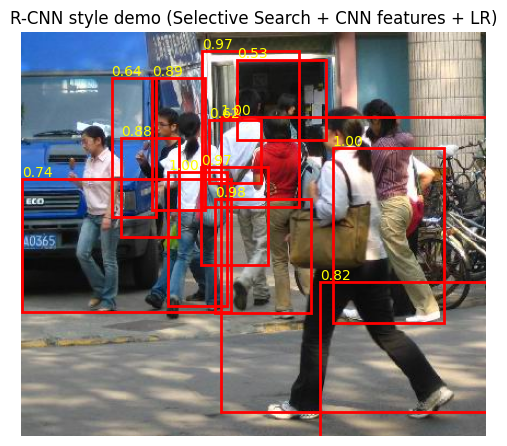

In [10]:

# Validate on one val image + visualize detections after NMS
import numpy as np, matplotlib.pyplot as plt, cv2

img, tgt = val_ds[0]
img_np = (img.permute(1,2,0).numpy()*255).astype(np.uint8)
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
rects = get_ss_proposals(img_bgr, mode='f')[:400]

boxes, scores = [], []
for (x,y0,w,h) in rects:
    box = np.array([x, y0, x+w, y0+h], dtype=np.float32)
    if w<20 or h<20: 
        continue
    feat = crop_and_feat(img, box)
    if feat is None:
        continue
    s = clf.predict_proba([feat])[0,1]
    if s > 0.5:
        boxes.append(box); scores.append(s)

def nms(boxes, scores, iou_thr=0.3):
    idxs = np.argsort(scores)[::-1]
    keep = []
    while len(idxs) > 0:
        i = idxs[0]
        keep.append(i)
        rest = idxs[1:]
        suppress = []
        for j in rest:
            if iou_xyxy(boxes[i], boxes[j]) > iou_thr:
                suppress.append(j)
        idxs = np.array([j for j in rest if j not in suppress])
    return [boxes[i] for i in keep], [scores[i] for i in keep]

boxes_nms, scores_nms = nms(boxes, scores, 0.3)
print("After NMS:", len(boxes_nms))

plt.figure(figsize=(6,6))
plt.imshow(img_np)
ax = plt.gca()
for b, s in zip(boxes_nms, scores_nms):
    x1,y1,x2,y2 = b
# NOTE: Matplotlib uses edgecolor to set box outline color. We choose 'red'.
    ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor='red'))
    ax.text(x1, y1-2, f"{s:.2f}",color='yellow')
plt.title("R-CNN style demo (Selective Search + CNN features + LR)")
plt.axis('off')
plt.show()


## 3.1 Full **R-CNN** Training Pipeline (Classifier + Box Regressor)

We now move from a tiny demo to a **complete, train/eval pipeline** for classic **R-CNN** on Penn-Fudan:

**Train:**
1) Generate proposals via Selective Search for each image.  
2) Label each proposal by IoU with the best ground-truth box (≥0.5 = positive, ≤0.3 = negative; ignore middle).  
3) Extract **ResNet-50** features for each proposal crop (frozen backbone).  
4) Train a **logistic regression** (person vs. background) and a **ridge regressor** for 4 box deltas \((t_x,t_y,t_w,t_h)\).

**Inference:** score proposals → keep high scores → apply box deltas → **NMS** → final detections.

This is slower than modern two-stage methods, but it is faithful to the original R-CNN idea and fully end‑to‑end for our small dataset.


In [ ]:

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.utils import shuffle
import numpy as np, torch, torchvision, cv2, math

# Reuse feat_extractor and gap from earlier (ResNet-50). If not defined, define them here.
try:
    feat_extractor
except NameError:
    from torchvision.models import resnet50
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    feat_extractor = resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).to(device).eval()
    gap = torch.nn.AdaptiveAvgPool2d((1,1))

def crop_features_batch(img_t, boxes, size=224, batch=16):
    feats_all = []
    for i in range(0, len(boxes), batch):
        batch_boxes = boxes[i:i+batch]
        crops = []
        for (x1,y1,x2,y2) in batch_boxes:
            x1=int(max(0,x1)); y1=int(max(0,y1)); x2=int(min(img_t.shape[2]-1,x2)); y2=int(min(img_t.shape[1]-1,y2))
            crop = img_t[:, y1:y2, x1:x2]
            if crop.numel()==0 or crop.shape[1]<2 or crop.shape[2]<2:
                crop = torch.zeros(3,size,size)  # blank
            crop = torchvision.transforms.functional.resize(crop, (size,size))
            crop = torchvision.transforms.functional.normalize(crop, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
            crops.append(crop)
        crops = torch.stack(crops,0).to(device)
        with torch.no_grad():
            x = feat_extractor.conv1(crops); x = feat_extractor.bn1(x); x = feat_extractor.relu(x); x = feat_extractor.maxpool(x)
            x = feat_extractor.layer1(x); x = feat_extractor.layer2(x); x = feat_extractor.layer3(x); x = feat_extractor.layer4(x)
            x = gap(x).flatten(1).cpu().numpy()  # [B,2048]
        feats_all.append(x)
    return np.concatenate(feats_all,0) if feats_all else np.zeros((0,2048), dtype=np.float32)

def bbox_transform(proposal, gt):
    # proposal, gt: [x1,y1,x2,y2]
    px, py, pw, ph = proposal[0], proposal[1], max(1.0, proposal[2]-proposal[0]), max(1.0, proposal[3]-proposal[1])
    gx, gy, gw, gh = gt[0], gt[1], max(1.0, gt[2]-gt[0]),      max(1.0, gt[3]-gt[1])
    tx = ( ( (gx+gw/2) - (px+pw/2) ) / pw )
    ty = ( ( (gy+gh/2) - (py+ph/2) ) / ph )
    tw = math.log(gw/pw)
    th = math.log(gh/ph)
    return np.array([tx,ty,tw,th], dtype=np.float32)

def bbox_apply(proposal, deltas):
    px, py, pw, ph = proposal[0], proposal[1], max(1.0, proposal[2]-proposal[0]), max(1.0, proposal[3]-proposal[1])
    dx,dy,dw,dh = deltas
    cx = (px+pw/2) + dx*pw
    cy = (py+ph/2) + dy*ph
    w = pw*math.exp(dw); h = ph*math.exp(dh)
    x1 = cx - w/2; y1 = cy - h/2; x2 = cx + w/2; y2 = cy + h/2
    return np.array([x1,y1,x2,y2], dtype=np.float32)

def build_rcnn_training_set(ds, max_props_per_image=800):
    X_cls, y_cls = [], []
    X_reg, Y_reg = [], []
    for i in range(len(ds)):
        img, tgt = ds[i]
        img_np = (img.permute(1,2,0).numpy()*255).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        rects = get_ss_proposals(img_bgr, mode='f')[:max_props_per_image]
        gt_boxes = tgt['boxes'].numpy().astype(np.float32)

        # Build IoU and labels
        prop_boxes = []
        prop_labels = []
        prop_targets = []
        for (x,y,w,h) in rects:
            box = np.array([x, y, x+w, y+h], dtype=np.float32)
            if w<16 or h<16: continue
            ious = [iou_xyxy(box, g) for g in gt_boxes] if len(gt_boxes)>0 else []
            if len(ious)==0: 
                label = 0
            else:
                j = int(np.argmax(ious)); iou_max = ious[j]
                if iou_max >= 0.5:  # positive
                    label = 1
                    target = bbox_transform(box, gt_boxes[j])
                elif iou_max <= 0.3:  # negative
                    label = 0
                    target = None
                else:
                    continue  # ignore
            prop_boxes.append(box); prop_labels.append(label); prop_targets.append(target)

        if not prop_boxes: 
            continue
        prop_boxes = np.array(prop_boxes, dtype=np.float32)
        feats = crop_features_batch(img, prop_boxes, size=224, batch=16)

        # Balance positives/negatives
        labels = np.array(prop_labels, dtype=np.int64)
        pos_idx = np.where(labels==1)[0]
        neg_idx = np.where(labels==0)[0]
        if len(pos_idx)>0 and len(neg_idx)>0:
            # sample to 1:3 ratio
            k_pos = min(len(pos_idx), 64)
            k_neg = min(len(neg_idx), k_pos*3)
            sel = np.concatenate([np.random.choice(pos_idx, k_pos, replace=False),
                                  np.random.choice(neg_idx, k_neg, replace=False)])
            feats = feats[sel]; labels = labels[sel]
            prop_boxes = prop_boxes[sel]
            prop_targets = [prop_targets[s] for s in sel]

        X_cls.append(feats); y_cls.append(labels)
        # For regression use only positives
        pos_mask = labels==1
        if pos_mask.any():
            X_reg.append(feats[pos_mask])
            Y_reg.append(np.stack([t for t,l in zip(prop_targets, labels) if l==1],0))

    X_cls = np.concatenate(X_cls,0) if X_cls else np.zeros((0,2048))
    y_cls = np.concatenate(y_cls,0) if y_cls else np.zeros((0,), dtype=np.int64)
    X_reg = np.concatenate(X_reg,0) if X_reg else np.zeros((0,2048))
    Y_reg = np.concatenate(Y_reg,0) if Y_reg else np.zeros((0,4))
    return X_cls, y_cls, X_reg, Y_reg

np.random.seed(17)
Xc, yc, Xr, Yr = build_rcnn_training_set(train_ds, max_props_per_image=800)
print("Classifier set:", Xc.shape, yc.shape, "| Regressor set:", Xr.shape, Yr.shape)

clf_rcnn = LogisticRegression(max_iter=500, class_weight='balanced')
clf_rcnn.fit(Xc, yc)
print(" Trained R-CNN classifier")

reg_rcnn = Ridge(alpha=1.0)
if len(Xr)>0:
    reg_rcnn.fit(Xr, Yr)
    print(" Trained R-CNN bbox regressor")
else:
    print("No positive boxes found for regressor; skipping bbox regression.")


Classifier set: (8233, 2048) (8233,) | Regressor set: (494, 2048) (494, 4)
✔️ Trained R-CNN classifier
✔️ Trained R-CNN bbox regressor


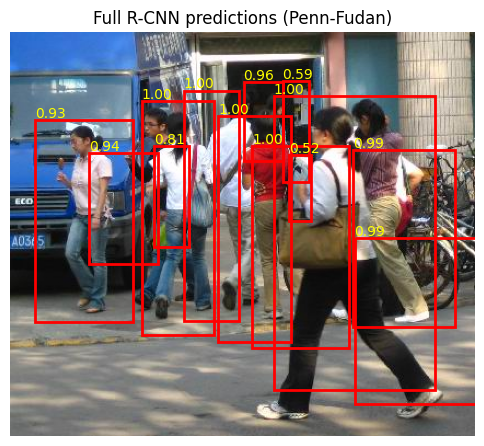

In [14]:

# Inference utilities for R-CNN
import numpy as np, cv2, torch, torchvision

def rcnn_predict_on_image(img, score_thr=0.5, topk=200, nms_iou=0.3):
    # img: FloatTensor [C,H,W] in [0,1]
    img_np = (img.permute(1,2,0).numpy()*255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    rects = get_ss_proposals(img_bgr, mode='f')[:1500]

    props = np.array([[x,y,x+w,y+h] for (x,y,w,h) in rects], dtype=np.float32)
    if len(props)==0:
        return np.zeros((0,4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    feats = crop_features_batch(img, props, size=224, batch=16)
    scores = clf_rcnn.predict_proba(feats)[:,1]

    # keep high scores
    idx = np.argsort(-scores)[:topk]
    props = props[idx]; scores = scores[idx]

    # apply bbox deltas if regressor was trained
    if hasattr(reg_rcnn, 'coef_') and reg_rcnn.coef_.size>0:
        deltas = reg_rcnn.predict(feats[idx])
        props_refined = np.stack([bbox_apply(p, d) for p,d in zip(props, deltas)],0)
    else:
        props_refined = props

    # NMS
    import torchvision
    boxes_t = torch.tensor(props_refined, dtype=torch.float32)
    scores_t = torch.tensor(scores, dtype=torch.float32)
    keep = torchvision.ops.nms(boxes_t, scores_t, iou_threshold=nms_iou).numpy()
    boxes_t = boxes_t[keep]; scores_t = scores_t[keep]
    # threshold
    keep2 = scores_t.numpy() >= score_thr
    return boxes_t.numpy()[keep2], scores_t.numpy()[keep2]

# Quick sanity visualization on one val image
import matplotlib.pyplot as plt
img, tgt = val_ds[0]
boxes, scores = rcnn_predict_on_image(img, score_thr=0.5)
plt.figure(figsize=(6,6)); plt.imshow(img.permute(1,2,0)); ax = plt.gca()
for b,s in zip(boxes, scores):
    x1,y1,x2,y2 = b
# NOTE: Matplotlib uses edgecolor to set box outline color. We choose 'red'.
    ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor='red'))
    ax.text(x1, y1-2, f"{s:.2f}", color='yellow')
plt.title("Full R-CNN predictions (Penn-Fudan)"); plt.axis('off'); plt.show()

In [15]:

# Evaluate R-CNN mAP@0.5 on the validation split (single class)
@torch.no_grad()
def evaluate_map_05_rcnn(ds):
    all_scores, all_tp, all_fp = [], [], []
    n_pos = 0
    for i in range(len(ds)):
        img, tgt = ds[i]
        gt = tgt['boxes'].numpy().astype(np.float32)
        n_pos += len(gt)
        boxes, scores = rcnn_predict_on_image(img, score_thr=0.0)
        # sort by score desc
        order = np.argsort(-scores)
        boxes = boxes[order]; scores = scores[order]
        matched = np.zeros(len(gt), dtype=bool)
        for b, s in zip(boxes, scores):
            if len(gt)==0:
                all_scores.append(s); all_tp.append(0); all_fp.append(1); continue
            ious = np.array([iou_xyxy(b, g) for g in gt])
            j = int(np.argmax(ious)); iou = ious[j]
            if iou >= 0.5 and not matched[j]:
                matched[j] = True
                all_scores.append(s); all_tp.append(1); all_fp.append(0)
            else:
                all_scores.append(s); all_tp.append(0); all_fp.append(1)
    if len(all_scores)==0:
        return 0.0
    order = np.argsort(-np.array(all_scores))
    tp = np.array(all_tp)[order].astype(np.float32)
    fp = np.array(all_fp)[order].astype(np.float32)
    tp_cum = np.cumsum(tp); fp_cum = np.cumsum(fp)
    recalls = tp_cum / max(n_pos,1)
    precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-6)
    ap = 0.0
    for t in np.linspace(0,1,11):
        p = precisions[recalls>=t].max() if np.any(recalls>=t) else 0
        ap += p/11.0
    return float(ap)

ap05_rcnn = evaluate_map_05_rcnn(val_ds)
print(f"R-CNN mAP@0.5 (val): {ap05_rcnn:.3f}")


R-CNN mAP@0.5 (val): 0.566



## 4. Demo: Fast R‑CNN (one backbone pass + ROI pooling)

Here we show the **core forward idea** of Fast R‑CNN using `torchvision.ops.roi_align`:
1. Run a CNN **once** to get a feature map.
2. Use region proposals (we’ll reuse a few from Selective Search) and **ROI Align** to get fixed 7×7 features.
3. Send them through a small head (2 FC layers) to get class logits + box regressions.


In [16]:

import torch
import torch.nn as nn
from torchvision.ops import roi_align
from torchvision.models import resnet50
import torchvision

backbone = resnet50(weights='DEFAULT').to(device).eval()

class FastHead(nn.Module):
    def __init__(self, in_channels=2048, roi_size=7, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(in_channels*roi_size*roi_size, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.cls_score = nn.Linear(1024, num_classes)
        self.bbox_pred = nn.Linear(1024, num_classes*4)

    def forward(self, x):
        x = x.flatten(1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.cls_score(x), self.bbox_pred(x)

img, tgt = train_ds[0]
img_in = img.unsqueeze(0).to(device)

with torch.no_grad():
    x = backbone.conv1(img_in); x = backbone.bn1(x); x = backbone.relu(x); x = backbone.maxpool(x)
    x = backbone.layer1(x); x = backbone.layer2(x); x = backbone.layer3(x); x = backbone.layer4(x)

# Take 3 GT boxes as proposals
boxes = tgt["boxes"][:3].clone()
rois = torch.cat([torch.zeros((boxes.size(0),1)), boxes], dim=1).to(device)
roi_feats = roi_align(x, rois, output_size=(7,7), spatial_scale=x.shape[-1]/img.shape[-1], aligned=True)

head = FastHead(in_channels=x.shape[1]).to(device)
cls_logits, bbox_regs = head(roi_feats)
print("ROI feats:", roi_feats.shape, "| cls logits:", cls_logits.shape, "| bbox regs:", bbox_regs.shape)


ROI feats: torch.Size([2, 2048, 7, 7]) | cls logits: torch.Size([2, 2]) | bbox regs: torch.Size([2, 8])



## 5. Faster R‑CNN: Fine‑tuning on Penn‑Fudan
We now switch to a **production‑ready** implementation from `torchvision.models.detection` and fine‑tune `fasterrcnn_resnet50_fpn` for a few epochs.


In [ ]:

import torch, time, torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn

num_classes = 2  # background + person
model_frcnn = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model_frcnn = model_frcnn.to(device)

params = [p for p in model_frcnn.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

def train_one_epoch(model, loader, optimizer, epoch, print_freq=20):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    for i,(images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) if torch.is_tensor(v) else v for k,v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        if (i+1) % print_freq == 0:
            print(f"Epoch {epoch} | batch {i+1}/{len(loader)} | loss={running_loss/(i+1):.3f}")
    dt = time.time()-t0
    return running_loss/len(loader), dt

EPOCHS = 5
history = []
for epoch in range(1, EPOCHS+1):
    loss, secs = train_one_epoch(model_frcnn, train_loader, optimizer, epoch)
    lr_scheduler.step()
    print(f"Epoch {epoch} done in {secs:.1f}s | avg loss {loss:.3f}")
    history.append((epoch, loss, secs))

print("Faster R-CNN trained (fine-tuned head)")


Epoch 1 | batch 20/51 | loss=0.423
Epoch 1 | batch 40/51 | loss=0.299
Epoch 1 done in 18.3s | avg loss 0.269
Epoch 2 | batch 20/51 | loss=0.114
Epoch 2 | batch 40/51 | loss=0.118
Epoch 2 done in 18.6s | avg loss 0.120
Epoch 3 | batch 20/51 | loss=0.085
Epoch 3 | batch 40/51 | loss=0.082
Epoch 3 done in 18.8s | avg loss 0.085
Epoch 4 | batch 20/51 | loss=0.085
Epoch 4 | batch 40/51 | loss=0.078
Epoch 4 done in 18.6s | avg loss 0.078
Epoch 5 | batch 20/51 | loss=0.082
Epoch 5 | batch 40/51 | loss=0.077
Epoch 5 done in 19.1s | avg loss 0.073
✔️ Faster R-CNN trained (fine-tuned head)



### 5.1 Evaluation: IoU, Precision/Recall, AP@0.5 


In [19]:

import numpy as np
import torch

def box_iou_matrix(boxes1, boxes2):
    if len(boxes1)==0 or len(boxes2)==0:
        return torch.zeros((len(boxes1), len(boxes2)), device=boxes1.device if len(boxes1)>0 else 'cpu')
    area1 = (boxes1[:,2]-boxes1[:,0]).clamp(min=0) * (boxes1[:,3]-boxes1[:,1]).clamp(min=0)
    area2 = (boxes2[:,2]-boxes2[:,0]).clamp(min=0) * (boxes2[:,3]-boxes2[:,1]).clamp(min=0)
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:,:,0]*wh[:,:,1]
    iou = inter / (area1[:,None] + area2 - inter + 1e-6)
    return iou

@torch.no_grad()
def evaluate_map_05(model, loader, score_thr=0.0):
    model.eval()
    all_scores, all_tp, all_fp = [], [], []
    n_positives = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            gt_boxes = tgt["boxes"].to(device)
            n_positives += gt_boxes.size(0)

            scores = out["scores"]
            keep = scores >= score_thr
            scores = scores[keep]
            boxes = out["boxes"][keep]

            order = torch.argsort(scores, descending=True)
            scores = scores[order]; boxes = boxes[order]

            matched = torch.zeros(len(gt_boxes), dtype=torch.bool, device=device)
            for s,b in zip(scores, boxes):
                if len(gt_boxes)==0:
                    all_scores.append(s.item())
                    all_tp.append(0); all_fp.append(1)
                    continue
                iou = box_iou_matrix(b.unsqueeze(0), gt_boxes).squeeze(0)
                m = torch.argmax(iou)
                if iou[m] >= 0.5 and not matched[m]:
                    matched[m] = True
                    all_scores.append(s.item()); all_tp.append(1); all_fp.append(0)
                else:
                    all_scores.append(s.item()); all_tp.append(0); all_fp.append(1)

    if len(all_scores)==0:
        return 0.0, []
    order = np.argsort(-np.array(all_scores))
    tp = np.array(all_tp)[order].astype(np.float32)
    fp = np.array(all_fp)[order].astype(np.float32)
    tp_cum = np.cumsum(tp); fp_cum = np.cumsum(fp)
    recalls = tp_cum / max(n_positives, 1)
    precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-6)
    ap = 0.0
    for t in np.linspace(0,1,11):
        p = precisions[recalls >= t].max() if np.any(recalls >= t) else 0
        ap += p / 11.0
    return float(ap), list(zip(recalls.tolist(), precisions.tolist()))


In [20]:

ap05, rp = evaluate_map_05(model_frcnn, val_loader, score_thr=0.0)
print(f"Faster R-CNN mAP@0.5 (val): {ap05:.3f}")


Faster R-CNN mAP@0.5 (val): 0.987


### 5.2 Inference & visualization

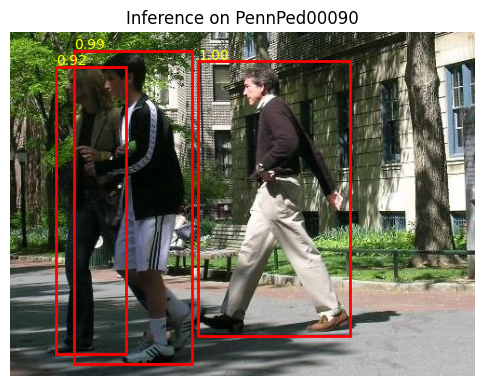

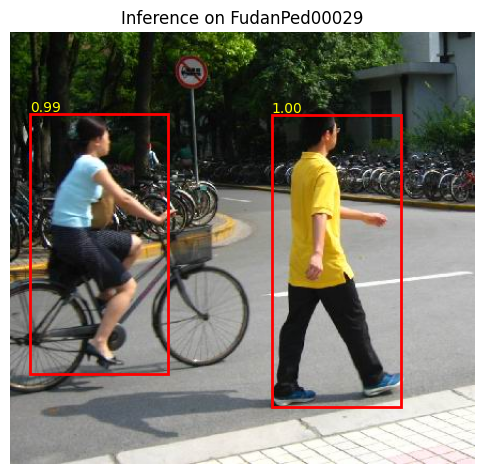

In [28]:

import matplotlib.pyplot as plt

@torch.no_grad()
def infer_and_show(model, ds, k=3, score_thr=0.5):
    model.eval()
    import numpy as np
    idxs = np.random.choice(len(ds), size=min(k, len(ds)), replace=False)
    for idx in idxs:
        img, tgt = ds[idx]
        out = model([img.to(device)])[0]
        img_np = img.permute(1,2,0).numpy()
        plt.figure(figsize=(6,6))
        plt.imshow(img_np); ax = plt.gca()
        for b,s in zip(out['boxes'], out['scores']):
            if s < score_thr: continue
            x1,y1,x2,y2 = b.cpu().numpy()
# NOTE: Matplotlib uses edgecolor to set box outline color. We choose 'red'.
            ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor='red'))
            ax.text(x1, y1-2, f"{s:.2f}", color='yellow')
        plt.title(f"Inference on {ds[idx][1]['img_name']}")
        plt.axis('off'); plt.show()

infer_and_show(model_frcnn, test_ds, k=2, score_thr=0.6)


## 6. Mask R‑CNN: Fine‑tuning on Penn‑Fudan (instance segmentation)


In [ ]:

from torchvision.models.detection import maskrcnn_resnet50_fpn

model_mrcnn = maskrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model_mrcnn.roi_heads.box_predictor.cls_score.in_features
model_mrcnn.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)
in_features_mask = model_mrcnn.roi_heads.mask_predictor.conv5_mask.in_channels
model_mrcnn.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, 256, 2)
model_mrcnn = model_mrcnn.to(device)

optimizer2 = torch.optim.SGD([p for p in model_mrcnn.parameters() if p.requires_grad],
                             lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=2, gamma=0.1)

EPOCHS2 = 5
for epoch in range(1, EPOCHS2+1):
    model_mrcnn.train()
    running = 0.0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) if torch.is_tensor(v) else v for k,v in t.items()} for t in targets]
        loss_dict = model_mrcnn(images, targets)
        loss = sum(loss_dict.values())
        optimizer2.zero_grad(); loss.backward(); optimizer2.step()
        running += loss.item()
    scheduler2.step()
    print(f"Mask R-CNN epoch {epoch} | loss {running/len(train_loader):.3f}")

print("Mask R-CNN trained (fine-tuned head)")


Mask R-CNN epoch 1 | loss 0.599
Mask R-CNN epoch 2 | loss 0.258
Mask R-CNN epoch 3 | loss 0.217
Mask R-CNN epoch 4 | loss 0.200
Mask R-CNN epoch 5 | loss 0.195
✔️ Mask R-CNN trained (fine-tuned head)


### 6.1 Evaluate boxes (mAP@0.5) and visualize masks

In [31]:
ap05_mrcnn, _ = evaluate_map_05(model_mrcnn, val_loader, score_thr=0.0)
print(f"Mask R-CNN (box) mAP@0.5 (val): {ap05_mrcnn:.3f}")

Mask R-CNN (box) mAP@0.5 (val): 0.985


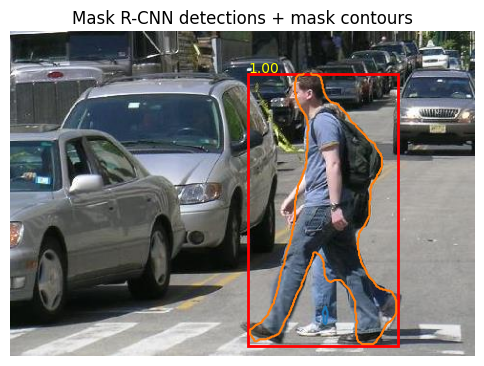

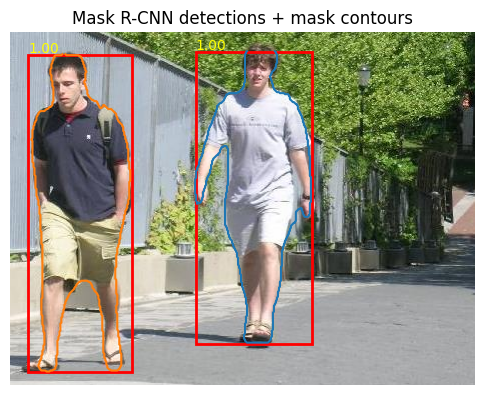

In [32]:

import matplotlib.pyplot as plt

@torch.no_grad()
def infer_and_show_masks(model, ds, k=3, score_thr=0.6, mask_thr=0.5):
    model.eval()
    import numpy as np, cv2
    idxs = np.random.choice(len(ds), size=min(k, len(ds)), replace=False)
    for idx in idxs:
        img, _ = ds[idx]
        out = model([img.to(device)])[0]
        img_np = img.permute(1,2,0).numpy()
        plt.figure(figsize=(6,6))
        plt.imshow(img_np); ax = plt.gca()
        for b,s,m in zip(out['boxes'], out['scores'], out['masks']):
            if s < score_thr: continue
            x1,y1,x2,y2 = b.cpu().numpy()
# NOTE: Matplotlib uses edgecolor to set box outline color. We choose 'red'.
            ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor='red'))
            ax.text(x1, y1-2, f"{s:.2f}", color='yellow')
            mask = (m[0].cpu().numpy() > mask_thr).astype(np.uint8)
            cnts, _ = cv2.findContours((mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for c in cnts:
                c = c.squeeze(1)
                if c.ndim == 2 and c.shape[0] > 2:
                    plt.plot(c[:,0], c[:,1])
        plt.title("Mask R-CNN detections + mask contours")
        plt.axis('off'); plt.show()

infer_and_show_masks(model_mrcnn, test_ds, k=2)


## 7. Compare Speed & Accuracy
We’ll measure **inference time per image** (on your machine) and our simplified **mAP@0.5** on the validation split.


In [33]:

import time, statistics

@torch.no_grad()
def time_inference(model, ds, n=10, warmup=2):
    model.eval()
    import numpy as np
    idxs = np.random.choice(len(ds), size=min(n, len(ds)), replace=False)
    times = []
    for idx in idxs[:warmup]:
        _ = model([ds[idx][0].to(device)])
    for idx in idxs[warmup:]:
        img = ds[idx][0].to(device)
        t0=time.time(); _=model([img]); t1=time.time()
        times.append(t1-t0)
    return statistics.mean(times) if times else float('nan')

frcnn_time = time_inference(model_frcnn, test_ds, n=8)
mrcnn_time = time_inference(model_mrcnn, test_ds, n=8)
print(f"Avg inference time (Faster R-CNN): {frcnn_time*1000:.1f} ms/img")
print(f"Avg inference time (Mask R-CNN):   {mrcnn_time*1000:.1f} ms/img")

print("Recomputing mAP@0.5 for both models...")
frcnn_ap, _ = evaluate_map_05(model_frcnn, val_loader)
mrcnn_ap, _ = evaluate_map_05(model_mrcnn, val_loader)
print(f"Faster R-CNN mAP@0.5: {frcnn_ap:.3f}")
print(f"Mask   R-CNN mAP@0.5: {mrcnn_ap:.3f}")


Avg inference time (Faster R-CNN): 73.8 ms/img
Avg inference time (Mask R-CNN):   82.7 ms/img
Recomputing mAP@0.5 for both models...
Faster R-CNN mAP@0.5: 0.987
Mask   R-CNN mAP@0.5: 0.985



## 8. Summary & What to Remember
- **R‑CNN:** external proposals + per‑proposal CNN → **accurate** but **slow**.
- **Fast R‑CNN:** 1 backbone pass + ROI Pool → **faster**, still external proposals.
- **Faster R‑CNN:** add **RPN** to learn proposals → strong **speed/accuracy** trade‑off.
- **Mask R‑CNN:** Faster R‑CNN + **mask branch** for **instance segmentation**.
- Training two‑stage detectors on small datasets is feasible with **transfer learning**.
- Understand **IoU**, **precision/recall**, and the idea of **AP/mAP** to evaluate detectors.


## 9. Exercises
1. Increase epochs to 6–8 and compare mAP@0.5. Does overfitting appear? Why?
2. Change backbone (e.g., `resnet50`→`mobilenet_v3_large`) using torchvision detection APIs and compare speed/accuracy.
3. Try **data augmentation** (random flips, color jitter). How does it affect generalization?
4. Modify `score_thr` and `mask_thr` during inference. How do precision & recall shift?
5. (Bonus) Replace our mini mAP code with `torchmetrics.detection.MAP`. Compare numbers.
6. (Bonus) Add another dataset class (e.g., **Oxford‑IIIT Pet**) and test Mask R‑CNN on cats/dogs.



## 10. Coming Up Next
In **Practical 18**, we'll work hands-on with  **YOLOv8**; you'll see how a one-stage detector differs from R-CNN-style two-stage models.


---
📝 This practical was designed by **Dr. Zaid Al-Huda** to give you hands-on with the **R-CNN** family—from **R-CNN** and **Fast**/**Faster R-CNN** to **Mask R-CNN**, covering **two-stage detection** (**region proposals** via **Selective Search**/**RPN**), **RoI Pooling** vs. **RoI Align**, and the mask head.